In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
import sys
sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
from read_datasets import read_dataset

In [2]:
year = '2020'
month = '07'

ds_ghi = read_dataset(
    dataset='barra-r2',
    resolution='hourly',
    date=f'{year}-{month}'
)

2026-02-06 11:03:10,357:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)

No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)



In [3]:
wf = 'maxcl'

mask_var_names = {
    'maxcl': 'FLAG',
    'mincl': 'INPUT',
}

def preprocess(_ds):
    # assign lat/lon values if missing
    if wf == 'maxcl':
        lat_vals = np.linspace(-90, 90, 361)
        lon_vals = np.linspace(-180, 179.75, 720)
        
        _ds = _ds.assign_coords(
            lat=lat_vals,
            lon=lon_vals
        )
    return _ds.sel(
        lat=slice(ds_ghi.lat.min(), ds_ghi.lat.max()),
        lon=slice(ds_ghi.lon.min(), ds_ghi.lon.max())
    )
wf_path = Path(f'/g/data/su28/weatherfeatures.era5/{wf}/')
wf_files = [f for f in wf_path.rglob(f'*{year}_{month}*.nc')]
ds_wf = xr.open_mfdataset(wf_files) #, preprocess=preprocess)
if wf == 'mincl':
    ds_wf = ds_wf.isel(dimz_INPUT=0)

In [4]:
ds_wf = ds_wf.interp(
    lat=ds_ghi.lat,
    lon=ds_ghi.lon,
    method='nearest'
)

In [5]:
ds_ghi_shifted = ds_ghi.assign_coords(time=ds_ghi.time - pd.Timedelta('30min'))
ds_ghi_times = ds_ghi_shifted.sel(time=ds_wf.time)

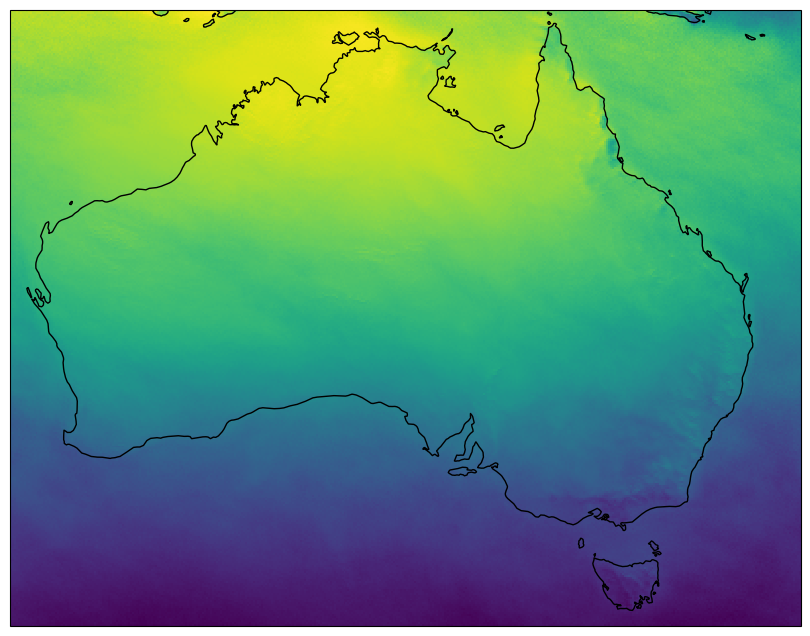

In [6]:
mask_var = mask_var_names[wf]
mask = ds_wf[mask_var]
data = xr.where(mask != 0, ds_ghi_times.ghi, np.nan).mean(dim='time')

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
mesh = ax.pcolormesh(
    data.lon,
    data.lat,
    data,
    cmap='viridis',
    shading='auto',
    transform=ccrs.PlateCarree(),
)
ax.coastlines()